In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load dataset

df = pd.read_csv("data/spam.csv", encoding="latin-1")


In [4]:
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [6]:
# Remove unnecessary columns

df = df[['v1', 'v2']]

# Rename columns

df.columns = ['Category', 'Message']

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
print("Shape:", df.shape)

Shape: (5572, 2)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [9]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [10]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

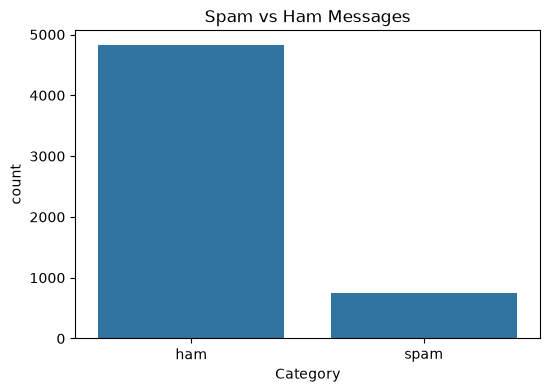

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x='Category', data=df)

plt.title("Spam vs Ham Messages")

plt.show()

In [12]:
df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})

In [13]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
# Features and target

X = df['Message']
y = df['Category']

In [15]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Convert text into numerical features

vectorizer = TfidfVectorizer(stop_words='english')

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print("TF-IDF Vectorization Completed!")

TF-IDF Vectorization Completed!


In [17]:
# Train Naive Bayes model

model = MultinomialNB()

model.fit(X_train, y_train)

print("Spam Detection Model Trained Successfully!")

Spam Detection Model Trained Successfully!


In [18]:
# Predictions

y_pred = model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9668161434977578


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



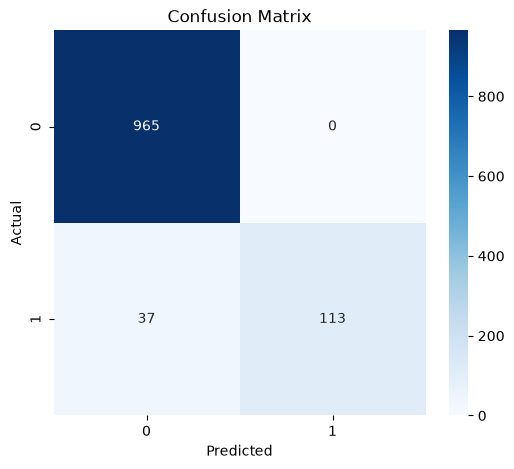

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
# Predict a custom message

message = "Congratulations! You have won a FREE iPhone. Click here to claim your prize."

message_vector = vectorizer.transform([message])

prediction = model.predict(message_vector)

print("Message:")
print(message)

if prediction[0] == 1:
    print("\n🚫 Spam Message")
else:
    print("\n✅ Ham (Not Spam)")

Message:
Congratulations! You have won a FREE iPhone. Click here to claim your prize.

🚫 Spam Message
